# UNIVERSIDAD NACIONAL MAYOR DE SAN MARCOS
## Facultad de Ingeniería de Sistemas e Informática (FISI)
### Escuela Profesional de Ingeniería de Sistemas

---

**Asignatura:** Inteligencia Artificial
**Laboratorio:** Semana 3 — Métodos de Búsqueda en Espacios de Estados
**Proyecto:** Optimización de una Ruta Logística en Lima Metropolitana con Algoritmos de Búsqueda Ciega e Informada
**Alumnos:**
- Calero Falcon, Gonzalo Manuel
- Huanacuni Gomez, Jean Carlos Josue

**Docente:** Prof. Hugo Vega
**Lima, Perú — 2026**

---

## Índice del laboratorio

1. Planteamiento del problema y contexto de ingeniería
2. Importación de librerías
3. El problema formalizado como grafo: nodos, distancias y heurística
4. Visualización del grafo del espacio de estados
5. ¿Por qué falla la búsqueda ciega por fuerza bruta? (explosión combinatorial)
6. Implementación de los algoritmos de búsqueda (BFS, DFS, UCS, Greedy y A*)
7. Ejecución y comparación de resultados
8. Preguntas conceptuales de autoevaluación
9. Conclusiones



# 1. Planteamiento del problema
### 1.1 Pregunta
Cuando abrimos Google Maps o Waze para ir de un distrito a otro, la aplicación no
prueba calles al azar ni pregunta a una persona. **¿Cómo hace la computadora para
encontrar, en milésimas de segundo, la ruta más corta entre miles de calles
posibles?** Ese es el problema de ingeniería que resolvemos en este laboratorio.

### 1.2 Contexto del problema
Una empresa de transporte de suministros médicos tiene su almacén central en el
**Puerto del Callao** y debe entregar un lote de vacunas en el **Hospital de
Emergencias de Villa El Salvador**, en el sur de Lima Metropolitana. La red vial
entre ambos puntos está compuesta por varios distritos e intersecciones conectados
por avenidas principales. Necesitamos decidir **qué ruta tomar** y, sobre todo,
**cómo debe razonar la computadora** para encontrarla.

### 1.3 Enunciado formal del problema
> *"Modelar la red vial entre el Callao y Villa El Salvador como un problema de
> búsqueda en un espacio de estados, e implementar y comparar distintos algoritmos
> (ciegos e informados) que encuentren una ruta desde el almacén hasta el
> hospital, evaluando su costo real, su optimalidad y cuántos nodos necesitó
> explorar cada uno."*

### 1.4 Los cinco componentes formales de un problema de búsqueda
Todo problema de búsqueda (Russell & Norvig, 2021) se define con cinco elementos.
Así se ven en nuestro caso:

| Elemento | Definición general | En este laboratorio |
|---|---|---|
| **Estado inicial** | Dónde comienza el agente | Almacén en el Callao (nodo `A`) |
| **Acciones** | Movimientos legales disponibles | Tomar una avenida hacia un distrito vecino |
| **Modelo de transición** | Qué pasa al aplicar una acción | Avanzar por una avenida lleva al distrito conectado |
| **Prueba de meta** | Cómo saber si ya llegamos | ¿Estamos en el Hospital de Villa El Salvador (nodo `Z`)? |
| **Costo de camino** | Precio de una trayectoria | Suma de los kilómetros reales recorridos |

### 1.5 Búsqueda ciega vs. búsqueda informada
- **Búsqueda ciega (no informada):** no sabe en qué dirección queda la meta;
  solo distingue si ya llegó o no. Ejemplos: BFS, DFS, UCS.
- **Búsqueda informada (heurística):** usa una "brújula matemática" `h(n)` que
  estima cuánto falta para llegar a la meta. Ejemplos: Greedy y A*.

Implementaremos ambos tipos sobre el mismo mapa para comparar, con hechos y
números, por qué uno es mejor que el otro.

# 2. Importación de librerías

Usamos solo herramientas básicas: estructuras de datos de la librería estándar de
Python para los algoritmos, y `pandas`/`matplotlib`/`networkx` para mostrar los
resultados de forma clara.

In [ ]:
# ---------------------------------------------------------------------------
# 2.1 Librerías de la librería estándar de Python (para los algoritmos)
# ---------------------------------------------------------------------------
import heapq                 # Cola de prioridad: la usan UCS, Greedy y A*
from collections import deque  # Cola FIFO: la usa BFS

# ---------------------------------------------------------------------------
# 2.2 Librerías para manejo de datos y gráficos
# ---------------------------------------------------------------------------
import pandas as pd              # Tabla comparativa de resultados
import matplotlib.pyplot as plt  # Gráficos de barras
import networkx as nx            # Dibujar el grafo del mapa

plt.rcParams['axes.grid'] = True
PALETA = {'ham': '#2E86AB', 'spam': '#E63946'}  # (paleta reutilizable, no se usa aquí)

print('[OK] Entorno de Python inicializado correctamente.')

[OK] Entorno de Python inicializado correctamente.


# 3. El problema formalizado como grafo: nodos, distancias y heurística

### 3.1 Idea general
Representamos la red vial como un **grafo**: cada distrito es un nodo y cada
avenida es una arista con un costo real en kilómetros `g`. Además, para cada
distrito calculamos su **distancia en línea recta** hasta el hospital meta — esa
es la heurística `h(n)` que usarán los algoritmos informados (sección 6).

### 3.2 ¿Por qué la distancia en línea recta es una heurística válida?
Porque **nunca puede ser mayor que la distancia real** por carretera (la línea
recta es, por geometría, el camino más corto posible entre dos puntos). Esta
propiedad se llama **admisibilidad** y es la que garantiza que A* encuentre
siempre la ruta óptima (sección 6.4 del informe).

### 3.3 El mapa: 10 distritos entre el Callao y Villa El Salvador

In [ ]:
# ---------------------------------------------------------------------------
# 3.4 Grafo del mapa: cada nodo apunta a sus vecinos con el costo real (km)
# ---------------------------------------------------------------------------
grafo = {
    'A': {'B': 7.0, 'C': 11.0},
    'B': {'A': 7.0, 'D': 6.5},
    'C': {'A': 11.0, 'D': 5.0, 'E': 6.0},
    'D': {'B': 6.5, 'C': 5.0, 'F': 7.0, 'G': 8.0},
    'E': {'C': 6.0, 'F': 5.5},
    'F': {'D': 7.0, 'E': 5.5, 'I': 6.0},
    'G': {'D': 8.0, 'H': 5.0},
    'H': {'G': 5.0, 'Z': 10.0},
    'I': {'F': 6.0, 'Z': 8.4},
    'Z': {'H': 10.0, 'I': 8.4},
}

# Heurística h(n): distancia en línea recta (km) de cada distrito hasta la meta Z
heuristica = {
    'A': 28.0, 'B': 22.0, 'C': 24.0, 'D': 17.5, 'E': 20.0,
    'F': 14.0, 'G': 13.0, 'H': 9.5, 'I': 7.0, 'Z': 0.0,
}

# Nombres reales de cada nodo, solo para que las tablas sean legibles
nombres = {
    'A': 'Callao (Almacén)', 'B': 'San Miguel', 'C': 'Centro de Lima',
    'D': 'San Isidro', 'E': 'La Victoria', 'F': 'Surco (Trébol)',
    'G': 'Barranco', 'H': 'Chorrillos', 'I': 'San Juan de Miraflores',
    'Z': 'Villa El Salvador (Hospital)',
}

INICIO, META = 'A', 'Z'

tabla_nodos = pd.DataFrame({
    'Nodo': list(grafo.keys()),
    'Distrito': [nombres[n] for n in grafo],
    'h(n) — distancia en línea recta a la meta (km)': [heuristica[n] for n in grafo],
})
tabla_nodos

,Nodo,Distrito,h(n) — distancia en línea recta a la meta (km)
0,A,Callao (Almacén),28.0
1,B,San Miguel,22.0
2,C,Centro de Lima,24.0
3,D,San Isidro,17.5
4,E,La Victoria,20.0
5,F,Surco (Trébol),14.0
6,G,Barranco,13.0
7,H,Chorrillos,9.5
8,I,San Juan de Miraflores,7.0
9,Z,Villa El Salvador (Hospital),0.0


### 3.5 Inspección visual del grafo
Antes de programar los algoritmos, dibujemos el mapa para verlo con nuestros
propios ojos.

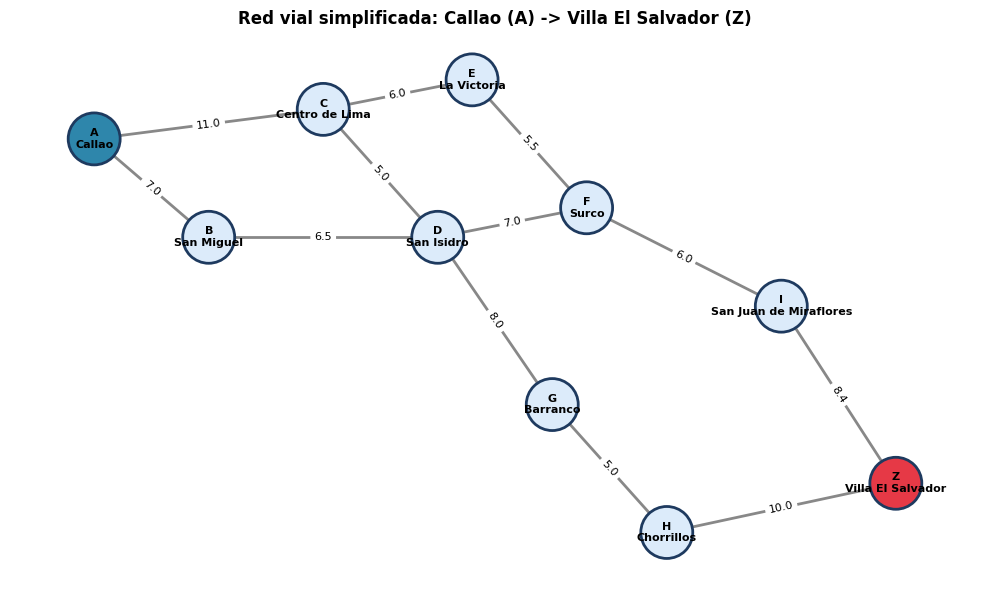

In [ ]:
# ---------------------------------------------------------------------------
# 4.1 Dibujo del grafo con networkx
# ---------------------------------------------------------------------------
G = nx.Graph()
for nodo, vecinos in grafo.items():
    for vecino, costo in vecinos.items():
        G.add_edge(nodo, vecino, weight=costo)

# Posiciones aproximadas (solo para que el dibujo se vea ordenado de norte a sur)
posiciones = {
    'A': (0, 5), 'B': (1, 4), 'C': (2, 5.3), 'D': (3, 4),
    'E': (3.3, 5.6), 'F': (4.3, 4.3), 'G': (4, 2.3), 'H': (5, 1),
    'I': (6, 3.3), 'Z': (7, 1.5),
}

plt.figure(figsize=(10, 6))
colores_nodo = ['#2E86AB' if n == INICIO else '#E63946' if n == META else '#DCEBFA'
                for n in G.nodes()]
nx.draw_networkx_nodes(G, posiciones, node_size=1400, node_color=colores_nodo,
                        edgecolors='#1E3A5F', linewidths=2)
etiquetas = {n: f"{n}\n{nombres[n].split(' (')[0]}" for n in G.nodes()}
nx.draw_networkx_labels(G, posiciones, labels=etiquetas, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G, posiciones, width=2, edge_color='#888888')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=nx.get_edge_attributes(G, 'weight'),
                              font_size=8)
plt.title('Red vial simplificada: Callao (A) -> Villa El Salvador (Z)', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**¿Qué nos dice este gráfico?**
El nodo azul (`A`, Callao) es el almacén de partida; el nodo rojo (`Z`, Villa El
Salvador) es el hospital meta. Existen **varios caminos posibles** para llegar de
uno a otro, con distinta cantidad de "saltos" y distinto costo acumulado en
kilómetros. Precisamente porque hay varias rutas posibles es que necesitamos un
algoritmo de búsqueda: alguien (o algo) tiene que decidir cuál de todos los
caminos conviene tomar.

# 5. ¿Por qué falla la búsqueda ciega por fuerza bruta?

### 5.1 Pregunta
Nuestro mapa tiene solo 10 distritos, así que revisar todos los caminos posibles
a mano no sería tan grave. **Pero, ¿qué pasaría con un mapa real, con miles de
intersecciones y un factor de ramificación mayor?**

### 5.2 La explosión combinatorial
Si en cada intersección hubiera en promedio `b` calles posibles, y quisiéramos
revisar **todos** los caminos posibles hasta una profundidad `d`, el número de
caminos a revisar crece como `b` elevado a `d`. Veamos qué tan rápido crece eso
para un cruce típico de `b = 4` calles por esquina.

In [ ]:
# ---------------------------------------------------------------------------
# 5.3 Demostración numérica de la explosión combinatorial
# ---------------------------------------------------------------------------
b = 4  # factor de ramificación: calles posibles en cada esquina
profundidades = list(range(1, 13))
caminos_posibles = [b ** d for d in profundidades]

tabla_explosion = pd.DataFrame({
    'Profundidad (pasos)': profundidades,
    'Caminos posibles a revisar (b^d)': caminos_posibles,
})
tabla_explosion['Caminos posibles a revisar (b^d)'] = \
    tabla_explosion['Caminos posibles a revisar (b^d)'].map('{:,}'.format)
tabla_explosion

,Profundidad (pasos),Caminos posibles a revisar (b^d)
0,1,4
1,2,16
2,3,64
3,4,256
4,5,"1,024"
5,6,"4,096"
6,7,"16,384"
7,8,"65,536"
8,9,"262,144"
9,10,"1,048,576"


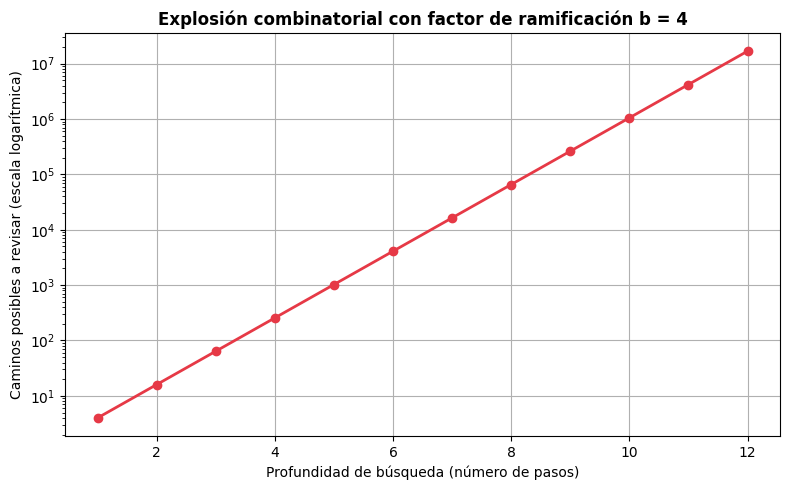

In [ ]:
# ---------------------------------------------------------------------------
# 5.4 Gráfico: crecimiento exponencial del número de caminos
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(profundidades, [b ** d for d in profundidades],
         marker='o', color='#E63946', linewidth=2)
plt.yscale('log')
plt.xlabel('Profundidad de búsqueda (número de pasos)')
plt.ylabel('Caminos posibles a revisar (escala logarítmica)')
plt.title(f'Explosión combinatorial con factor de ramificación b = {b}', fontweight='bold')
plt.tight_layout()
plt.show()

**¿Qué nos dice este gráfico?**
Con solo `b = 4` opciones por esquina, a los 12 pasos ya hay más de **16 millones**
de caminos posibles. En un mapa real de una ciudad, con `b` más grande y rutas de
decenas de pasos, revisar **todos** los caminos a ciegas es matemáticamente
inviable. Por eso necesitamos algoritmos que **organicen** la exploración
(BFS, DFS, UCS) y, mejor aún, algoritmos que usen una **heurística** para saber
hacia dónde conviene buscar primero (Greedy, A*), en vez de fuerza bruta pura.

# 6. Implementación de los algoritmos de búsqueda

Implementamos cinco algoritmos clásicos. Todos reciben el grafo, el nodo de
inicio y el nodo meta, y devuelven tres cosas: **la ruta encontrada**, **su costo
real en kilómetros** y **cuántos nodos tuvo que expandir** (una medida simple de
cuánto "trabajo" hizo el algoritmo).

### 6.1 Búsqueda en Anchura (BFS) — ciega
Explora nivel por nivel usando una cola FIFO. Encuentra la ruta con **menos
saltos**, no necesariamente la de menor costo en kilómetros.

In [ ]:
def costo_de_ruta(grafo, ruta):
    '''Suma los kilómetros reales de una ruta ya encontrada.'''
    return sum(grafo[ruta[i]][ruta[i + 1]] for i in range(len(ruta) - 1))


def bfs(grafo, inicio, meta):
    frontera = deque([[inicio]])
    visitados = {inicio}
    expandidos = 0
    while frontera:
        ruta = frontera.popleft()
        nodo = ruta[-1]
        expandidos += 1
        if nodo == meta:
            return ruta, costo_de_ruta(grafo, ruta), expandidos
        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                frontera.append(ruta + [vecino])
    return None, float('inf'), expandidos

### 6.2 Búsqueda en Profundidad (DFS) — ciega
Explora hasta el fondo de una rama con una pila LIFO antes de retroceder. Es la
que menos memoria usa, pero **no garantiza** encontrar la ruta más corta.

In [ ]:
def dfs(grafo, inicio, meta):
    frontera = [[inicio]]
    visitados = set()
    expandidos = 0
    while frontera:
        ruta = frontera.pop()
        nodo = ruta[-1]
        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos += 1
        if nodo == meta:
            return ruta, costo_de_ruta(grafo, ruta), expandidos
        for vecino in grafo[nodo]:
            if vecino not in visitados:
                frontera.append(ruta + [vecino])
    return None, float('inf'), expandidos

### 6.3 Búsqueda de Costo Uniforme (UCS / Dijkstra) — ciega
Usa una cola de prioridad ordenada por el costo acumulado real `g(n)`. A
diferencia de BFS, **sí garantiza** encontrar la ruta de menor costo, aunque no
sepa hacia dónde queda la meta.

In [ ]:
def ucs(grafo, inicio, meta):
    frontera = [(0.0, [inicio])]     # (costo acumulado g, ruta)
    visitados = set()
    expandidos = 0
    while frontera:
        costo, ruta = heapq.heappop(frontera)
        nodo = ruta[-1]
        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos += 1
        if nodo == meta:
            return ruta, costo, expandidos
        for vecino, paso in grafo[nodo].items():
            if vecino not in visitados:
                heapq.heappush(frontera, (costo + paso, ruta + [vecino]))
    return None, float('inf'), expandidos

### 6.4 Búsqueda Voraz (Greedy Best-First) — informada
Usa una cola de prioridad, pero ordenada **solo** por la heurística `h(n)`: va
siempre hacia el vecino que "parece" más cercano a la meta, sin mirar cuánto ya
gastó. Es rápida, pero puede llevar a rutas más caras (es "miope").

In [ ]:
def greedy(grafo, inicio, meta, heuristica):
    frontera = [(heuristica[inicio], [inicio])]   # (h(n), ruta)
    visitados = set()
    expandidos = 0
    while frontera:
        _, ruta = heapq.heappop(frontera)
        nodo = ruta[-1]
        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos += 1
        if nodo == meta:
            return ruta, costo_de_ruta(grafo, ruta), expandidos
        for vecino in grafo[nodo]:
            if vecino not in visitados:
                heapq.heappush(frontera, (heuristica[vecino], ruta + [vecino]))
    return None, float('inf'), expandidos

### 6.5 Algoritmo A* — informada
Combina lo mejor de UCS y Greedy con la fórmula `f(n) = g(n) + h(n)`: expande
siempre el nodo con menor **costo total proyectado**, mezclando el gasto real ya
hecho (`g`) con la estimación optimista de lo que falta (`h`). Con una heurística
admisible, **A\* garantiza encontrar la ruta óptima** explorando menos nodos que
UCS.

In [ ]:
def a_star(grafo, inicio, meta, heuristica):
    frontera = [(heuristica[inicio], 0.0, [inicio])]   # (f = g + h, g, ruta)
    visitados = set()
    expandidos = 0
    while frontera:
        f, g, ruta = heapq.heappop(frontera)
        nodo = ruta[-1]
        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos += 1
        if nodo == meta:
            return ruta, g, expandidos
        for vecino, paso in grafo[nodo].items():
            if vecino not in visitados:
                nuevo_g = g + paso
                nuevo_f = nuevo_g + heuristica[vecino]
                heapq.heappush(frontera, (nuevo_f, nuevo_g, ruta + [vecino]))
    return None, float('inf'), expandidos

# 7. Ejecución y comparación de resultados

Ejecutamos los cinco algoritmos sobre el mismo mapa, desde el almacén del Callao
(`A`) hasta el hospital de Villa El Salvador (`Z`), y comparamos sus rutas,
costos reales y cuántos nodos tuvo que expandir cada uno.

In [ ]:
# ---------------------------------------------------------------------------
# 7.1 Ejecutar los cinco algoritmos y guardar los resultados
# ---------------------------------------------------------------------------
algoritmos = {
    'BFS (ciega)': lambda: bfs(grafo, INICIO, META),
    'DFS (ciega)': lambda: dfs(grafo, INICIO, META),
    'UCS / Dijkstra (ciega)': lambda: ucs(grafo, INICIO, META),
    'Greedy (informada)': lambda: greedy(grafo, INICIO, META, heuristica),
    'A* (informada)': lambda: a_star(grafo, INICIO, META, heuristica),
}

resultados = []
for nombre, funcion in algoritmos.items():
    ruta, costo, expandidos = funcion()
    resultados.append({
        'Algoritmo': nombre,
        'Ruta encontrada': ' -> '.join(ruta),
        'Costo real (km)': round(costo, 1),
        'Nodos expandidos': expandidos,
    })

tabla_resultados = pd.DataFrame(resultados)

# Marcamos cuál es el costo mínimo real para poder comparar optimalidad
costo_optimo = tabla_resultados['Costo real (km)'].min()
tabla_resultados['¿Encontró la ruta óptima?'] = \
    tabla_resultados['Costo real (km)'].apply(lambda c: 'Sí' if c == costo_optimo else 'No')

tabla_resultados

,Algoritmo,Ruta encontrada,Costo real (km),Nodos expandidos,¿Encontró la ruta óptima?
0,BFS (ciega),A -> B -> D -> F -> I -> Z,34.9,10,Sí
1,DFS (ciega),A -> C -> E -> F -> I -> Z,36.9,6,No
2,UCS / Dijkstra (ciega),A -> B -> D -> F -> I -> Z,34.9,10,Sí
3,Greedy (informada),A -> B -> D -> G -> H -> Z,36.5,6,No
4,A* (informada),A -> B -> D -> F -> I -> Z,34.9,7,Sí


**¿Qué nos dice esta tabla?**
Todos los algoritmos llegan al hospital, pero **no todos llegan por el mismo
camino ni con el mismo esfuerzo**. UCS y A\* garantizan encontrar la ruta de
menor costo real; Greedy puede "confiarse" de la heurística y terminar en una
ruta más cara; BFS encuentra la ruta con menos saltos (que puede o no coincidir
con la más barata); y DFS simplemente reporta la primera ruta que encontró al
fondo de la primera rama que exploró.

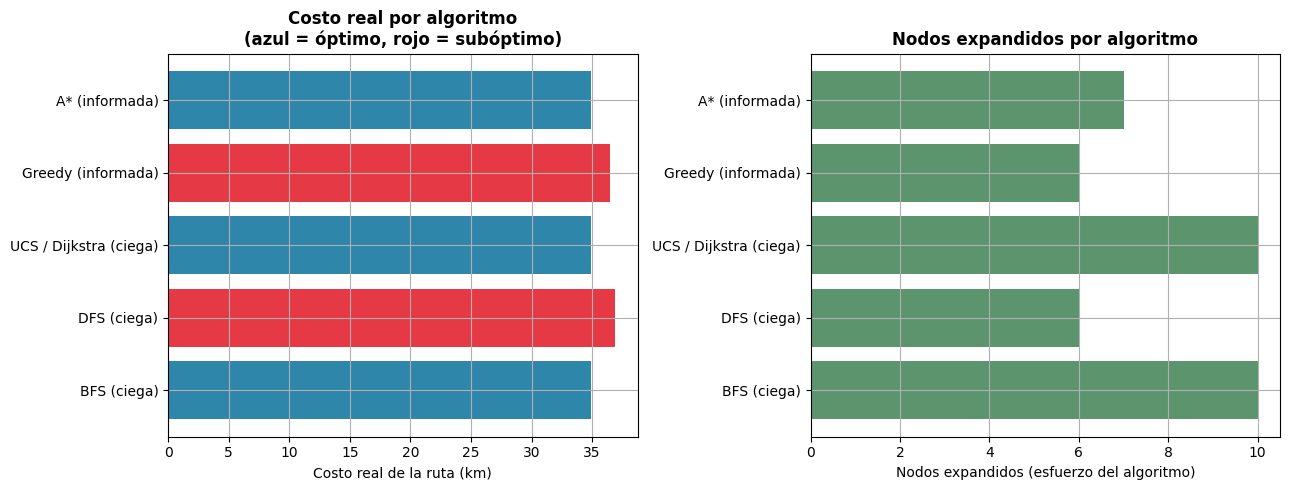

In [ ]:
# ---------------------------------------------------------------------------
# 7.2 Gráfico comparativo: costo real vs. nodos expandidos
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colores_barras = ['#2E86AB' if r == 'Sí' else '#E63946'
                   for r in tabla_resultados['¿Encontró la ruta óptima?']]

ax1.barh(tabla_resultados['Algoritmo'], tabla_resultados['Costo real (km)'],
          color=colores_barras)
ax1.set_xlabel('Costo real de la ruta (km)')
ax1.set_title('Costo real por algoritmo\n(azul = óptimo, rojo = subóptimo)', fontweight='bold')

ax2.barh(tabla_resultados['Algoritmo'], tabla_resultados['Nodos expandidos'],
          color='#5C946E')
ax2.set_xlabel('Nodos expandidos (esfuerzo del algoritmo)')
ax2.set_title('Nodos expandidos por algoritmo', fontweight='bold')

plt.tight_layout()
plt.show()

**¿Qué nos dice este gráfico?**
El panel izquierdo muestra qué tan cara resultó cada ruta: los algoritmos en azul
(UCS y A\*) sí encontraron el camino más barato. El panel derecho muestra el
esfuerzo de cálculo: **A\* llega al mismo resultado óptimo que UCS, pero
expandiendo menos nodos**, porque la heurística lo guía directamente hacia el sur
en vez de explorar en todas las direcciones por igual. Ese es, en una sola
imagen, el motivo por el cual A\* es el estándar de oro de la búsqueda
informada.

# 8. Preguntas de Reflexion:

**1. ¿Cuál es la diferencia esencial entre un algoritmo de búsqueda ciego y uno
informado?**
El algoritmo ciego (BFS, DFS, UCS) no tiene ninguna estimación de qué tan cerca
está de la meta; solo sabe distinguir si ya llegó o no. El algoritmo informado
(Greedy, A\*) usa una heurística `h(n)` que estima el costo restante, lo que le
permite orientar la búsqueda directamente hacia la meta.

**2. ¿Por qué A\* encontró la ruta óptima expandiendo menos nodos que UCS, si
ambos garantizan optimalidad?**
Porque UCS explora "a ciegas" en todas las direcciones por igual, sin saber que
el hospital queda al sur; en cambio, A\* usa `f(n) = g(n) + h(n)`, y como `h(n)`
apunta hacia el sur, descarta antes las ramas que se alejan de la meta, sin dejar
de garantizar que la solución encontrada sea la más barata.

**3. ¿Por qué la ruta de Greedy no fue la más barata, si Greedy sí llegó al
hospital?**
Porque Greedy solo mira `h(n)` (qué tan cerca "parece" estar de la meta) y no
suma el costo real ya gastado `g(n)`. Puede avanzar por un distrito que se ve muy
cercano en línea recta pero que, en la práctica, termina en un desvío con más
kilómetros reales.

**4. ¿Qué propiedad debe cumplir la heurística para que A\* garantice la
optimalidad?**
Debe ser **admisible**: nunca debe sobreestimar el costo real que falta para
llegar a la meta. La distancia en línea recta cumple esta propiedad porque, por
geometría, nunca puede ser mayor que la distancia real por carretera.

**5. Si el mapa tuviera 10,000 distritos en vez de 10, ¿qué algoritmo elegirías
y por qué?**
A\*, porque combina la garantía de optimalidad de UCS con la eficiencia de
explorar muchos menos nodos gracias a la heurística — una diferencia que se
vuelve crítica quando el grafo crece, como demostramos en la sección 5 con la
explosión combinatorial.

# 9. Conclusiones

### 9.1 Conclusiones del laboratorio
1. **Todo problema de búsqueda se puede formalizar** con cinco componentes
   (estado inicial, acciones, modelo de transición, prueba de meta y costo de
   camino), lo que permite modelar desde un mapa de calles hasta un rompecabezas.
2. **La búsqueda ciega funciona, pero no escala**: BFS y UCS garantizan
   encontrar una buena ruta, pero exploran el mapa sin ninguna orientación, lo
   que se vuelve inviable en grafos grandes (sección 5).
3. **La heurística es la clave de la eficiencia**: al incorporar una estimación
   admisible del costo restante, A\* encuentra la misma ruta óptima que UCS
   explorando muchos menos nodos, y Greedy demuestra que una heurística usada
   *sin* el costo real acumulado puede llevar a decisiones subóptimas.

### 9.2 Aplicaciones reales de esta misma idea
- **Navegación GPS (Google Maps, Waze):** variantes de A\* y Dijkstra sobre
  grafos de millones de intersecciones.
- **Videojuegos:** personajes no jugables que persiguen al jugador usando A\*
  sobre una malla de navegación (*NavMesh*).
- **Internet:** el protocolo OSPF usa una versión de Dijkstra para enrutar
  paquetes de datos por la ruta con menor retardo.


### 9.3 Referencias
- Russell, S., & Norvig, P. (2021). *Artificial Intelligence: A Modern
  Approach* (4.ª ed.). Pearson.
- Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). *A Formal Basis for the
  Heuristic Determination of Minimum Cost Paths*. IEEE Transactions on Systems
  Science and Cybernetics, 4(2), 100–107.
- Dijkstra, E. W. (1959). *A note on two problems in connexion with graphs*.
  Numerische Mathematik, 1(1), 269–271.
- Documentación oficial de `networkx`: https://networkx.org/